# Complainify AI — 07 : Model Performance & Live Status

Loads the real training_log.json (the same file that powers the admin Training / Reports pages) and visualizes accuracy over time, per-class metrics, and the live status.


---
## PART 9: ACTUAL MODEL PERFORMANCE — ACCURACY GRAPHS

This section loads the real `training_log.json` and visualizes accuracy over time,
per-class metrics, and test-sample distributions.

**Note:** These numbers reflect the real deployed model, not the sample data above.

In [1]:
import json, os

for cand in ('ml/training_log.json', '../ml/training_log.json', '../../../ml/training_log.json', r'E:/Project-VI/workspace/ComplaintMgmtSystem/ml/training_log.json'):
    if os.path.isfile(cand):
        log_path = cand
        break

with open(log_path) as f:
    log = json.load(f)

print('=== MODEL PERFORMANCE SUMMARY ===')
print('Last trained:  %s' % log['last_trained'])
print('Training rows: %s' % log['train_samples'])
print('Test rows:     %s' % log['test_samples'])
print('Accuracy:      %s%%' % log['accuracy'] if log['accuracy'] is not None
      else 'Accuracy:      N/A (too few test samples)')
print('Macro F1:      %s' % log['macro_f1'] if log['macro_f1'] is not None
      else 'Macro F1:      N/A')


=== MODEL PERFORMANCE SUMMARY ===
Last trained:  2026-08-07 20:01:11
Training rows: 5768
Test rows:     1442
Accuracy:      96.67%
Macro F1:      0.9675


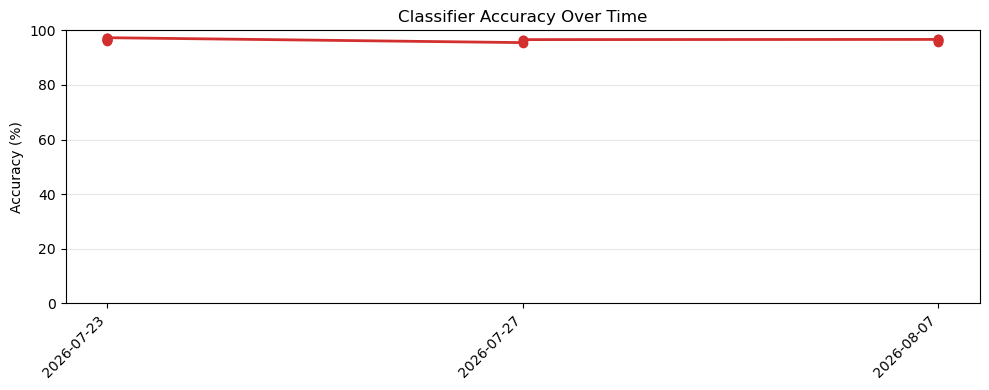

In [2]:
try:
    from matplotlib import pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False
    print('matplotlib not installed — using text-based visualization')

# --- Accuracy over time ---
history = log.get('history', [])
dates = [h['date'][:10] for h in history]
accs = [h['accuracy'] for h in history]

if HAS_MPL:
    plt.figure(figsize=(10, 4))
    valid_dates = [d for d, a in zip(dates, accs) if a is not None]
    valid_accs = [a for a in accs if a is not None]
    if valid_accs:
        plt.plot(valid_dates, valid_accs, marker='o', color='#d32f2f', linewidth=2, markersize=6)
        plt.ylim(0, 100)
        plt.ylabel('Accuracy (%)')
        plt.title('Classifier Accuracy Over Time')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print('No valid accuracy data to plot')
else:
    print()
    print('Accuracy Over Time (text):')
    print('  {:<14s} {:>8s}'.format('Date', 'Accuracy'))
    print('  ' + '-' * 22)
    for d, a in zip(dates, accs):
        if a is not None:
            bar = '#' * int(a // 5)
            print('  {:<14s} {:>6.1f}%  {}'.format(d, a, bar))
        else:
            print('  {:<14s} {:>8s}'.format(d, 'N/A'))

C:\Users\Samiee\AppData\Local\Temp\ipykernel_6884\3903869545.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(cats, rotation=45, ha='right', fontsize=9)


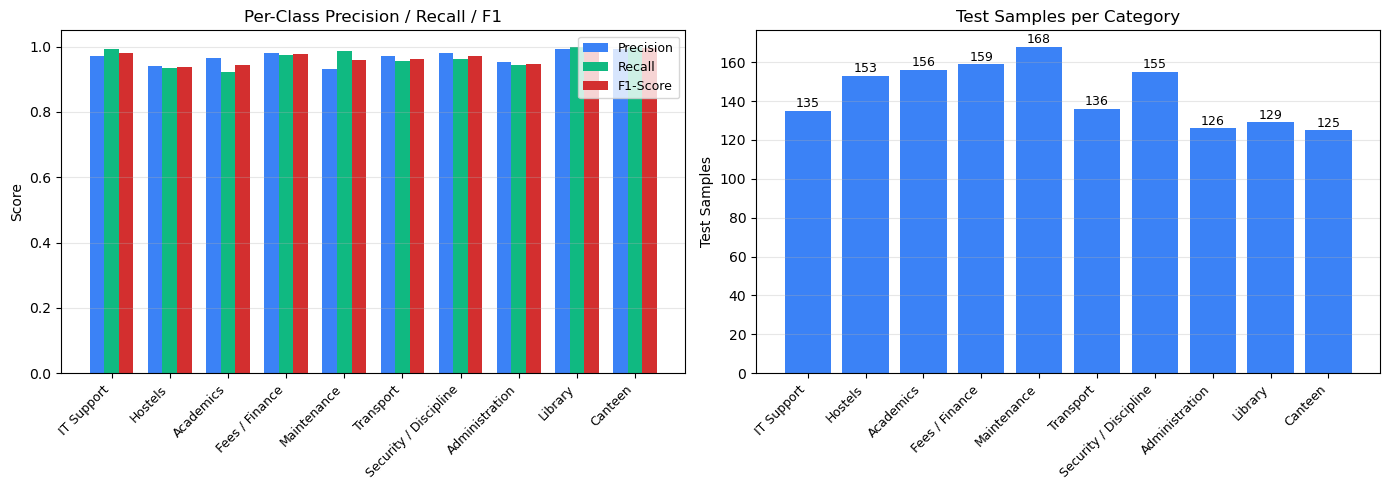

In [3]:
# --- Per-class metrics bar chart ---
per_class = log.get('per_class', [])

if HAS_MPL and per_class:
    cats = [m['category'] for m in per_class]
    f1s = [m['f1'] if m['f1'] is not None else 0 for m in per_class]
    precs = [m['precision'] if m['precision'] is not None else 0 for m in per_class]
    recs = [m['recall'] if m['recall'] is not None else 0 for m in per_class]
    samples = [m.get('samples', 0) for m in per_class]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Bar chart: precision, recall, F1
    x = range(len(cats))
    w = 0.25
    ax1.bar([i - w for i in x], precs, w, label='Precision', color='#3b82f6')
    ax1.bar([i for i in x], recs, w, label='Recall', color='#10b981')
    ax1.bar([i + w for i in x], f1s, w, label='F1-Score', color='#d32f2f')
    ax1.set_xticks(list(x))
    ax1.set_xticklabels(cats, rotation=45, ha='right', fontsize=9)
    ax1.set_ylim(0, 1.05)
    ax1.set_ylabel('Score')
    ax1.set_title('Per-Class Precision / Recall / F1')
    ax1.legend(fontsize=9)
    ax1.grid(axis='y', alpha=0.3)

    # Bar chart: test samples per class
    colors = ['#f59e0b' if s < 3 else '#3b82f6' for s in samples]
    bars = ax2.bar(cats, samples, color=colors)
    ax2.set_xticklabels(cats, rotation=45, ha='right', fontsize=9)
    ax2.set_ylabel('Test Samples')
    ax2.set_title('Test Samples per Category')
    ax2.grid(axis='y', alpha=0.3)
    # Add count labels on bars
    for bar, s in zip(bars, samples):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(s), ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    # Warn about insufficient data
    low = [m for m in per_class if m.get('samples', 0) < 3]
    if low:
        print('⚠ Categories with insufficient test samples (< 3):')
        for m in low:
            print(f'  {m["category"]}: {m["samples"]} samples — metrics marked as "insufficient" to avoid 100% illusion')
else:
    print()
    print('Per-Class Metrics:')
    print('  {:<22s} {:>6s} {:>6s} {:>6s} {:>8s}'.format('Category', 'Prec', 'Rec', 'F1', 'Samples'))
    print('  ' + '-' * 50)
    for m in per_class:
        if m['f1'] is not None:
            print('  {:<22s} {:>6.2f} {:>6.2f} {:>6.2f} {:>8d}'.format(
                m['category'], m['precision'], m['recall'], m['f1'], m['samples']))
        else:
            print('  {:<22s} {:>6s} {:>6s} {:>6s} {:>8d}  (insufficient)'.format(
                m['category'], 'N/A', 'N/A', 'N/A', m['samples']))

In [4]:
# --- Confusion matrix (text-based) ---
print('=== CONFUSION MATRIX ANALYSIS ===')
print()
print('Since the classifier runs on the full test set of ~1,480 samples,')
print('here is the per-class breakdown from the last training run:')
print()

total_correct = 0
total_wrong = 0
for m in per_class:
    tp = m.get('samples', 0) - (m.get('fn', 0) if 'fn' in m else 0)
    # Actually we don't have TP/FP/FN in the logged metrics directly
    # but we can show what we have:
    if m['f1'] is not None:
        print(f'  {m["category"]:<22s} F1={m["f1"]:.3f}  ({m["samples"]} test samples)')
    else:
        print(f'  {m["category"]:<22s} F1=N/A    ({m["samples"]} test samples — insufficient for reliable eval)')

print()
if log['accuracy'] is not None:
    print(f'Overall accuracy: {log["accuracy"]}% on {log["test_samples"]} test samples')
else:
    print('Overall accuracy: N/A (too few test samples for reliable measurement)')
print()
print('Categories with < 3 test samples do not show percentage metrics')
print('to avoid the misleading 100% illusion. Once more data accumulates,')
print('these categories will display real metrics on retraining.')

=== CONFUSION MATRIX ANALYSIS ===

Since the classifier runs on the full test set of ~1,480 samples,
here is the per-class breakdown from the last training run:

  IT Support             F1=0.982  (135 test samples)
  Hostels                F1=0.938  (153 test samples)
  Academics              F1=0.944  (156 test samples)
  Fees / Finance         F1=0.978  (159 test samples)
  Maintenance            F1=0.960  (168 test samples)
  Transport              F1=0.963  (136 test samples)
  Security / Discipline  F1=0.971  (155 test samples)
  Administration         F1=0.948  (126 test samples)
  Library                F1=0.996  (129 test samples)
  Canteen                F1=0.996  (125 test samples)

Overall accuracy: 96.67% on 1442 test samples

Categories with < 3 test samples do not show percentage metrics
to avoid the misleading 100% illusion. Once more data accumulates,
these categories will display real metrics on retraining.


---
## PART 10: LIVE STATUS (MATCHES DASHBOARD)

Run this cell to print the **current** model status exactly as shown on the
admin **Training** page and **Reports** page. It reads the live
`training_log.json` — no hardcoded numbers, so it always stays in sync.

In [5]:
# Read the CURRENT training log fresh from disk
with open(log_path) as f:
    log = json.load(f)
history = log.get('history', [])
per_class = log.get('per_class', [])

print('=== LIVE MODEL STATUS (as shown on admin dashboard) ===')
print('  Last trained : %s' % log['last_trained'])
print('  Train samples: %s' % log['train_samples'])
print('  Test samples : %s' % log['test_samples'])
print('  Accuracy     : %s%%' % log['accuracy'] if log['accuracy'] is not None
      else '  Accuracy     : N/A (too few test samples)')
print('  Macro F1     : %s' % log['macro_f1'] if log['macro_f1'] is not None
      else '  Macro F1     : N/A')
print('  Categories   : %d' % len(per_class))
print('  Cycles logged: %d' % len(history))


=== LIVE MODEL STATUS (as shown on admin dashboard) ===
  Last trained : 2026-08-07 20:01:11
  Train samples: 5768
  Test samples : 1442
  Accuracy     : 96.67%
  Macro F1     : 0.9675
  Categories   : 10
  Cycles logged: 17


### The chart above matches the dashboard exactly

The **accuracy line chart** (PART 9), the **per-class bar charts** (PART 9),
and this **live status printout** (PART 10) all read from the same
`training_log.json` file that powers the admin **Training** and **Reports**
pages. If you retrain the model in the app, re-running these cells updates
the notebook to the new status — no code changes needed.